In [6]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
import warnings
import pandas as pd


In [7]:
df=pd.read_csv('data/StudentsPerformance.csv')

In [8]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [10]:
X=df.drop(columns=['math score'])

In [11]:
Y=df['math score']

In [12]:
num_feature=X.select_dtypes(exclude='str').columns
cat_feature=X.select_dtypes(include='str').columns

from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

num_transformer=StandardScaler()
cat_transformer=OneHotEncoder()

preprocessor=ColumnTransformer(
  [
    ("onehotencoder",cat_transformer,cat_feature),
    ("standardscaler",num_transformer,num_feature)
  ]
)


In [13]:
X=preprocessor.fit_transform(X)

In [14]:
X

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]], shape=(1000, 19))

In [15]:
X.shape

(1000, 19)

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [18]:
X_train.shape,X_test.shape

((800, 19), (200, 19))

In [19]:
import numpy as np
def evaluate_model(true,predicted):
  mae=mean_absolute_error(true,predicted)
  mse=mean_squared_error(true,predicted)
  rmse=np.sqrt(mean_squared_error(true,predicted))
  score=r2_score(true,predicted)
  return mae,mse,score

In [21]:
models={
  "lR": LinearRegression(),
  "ridge": Ridge(),
  "lasso": Lasso(),
  "DT": DecisionTreeRegressor(),
  "KNN": KNeighborsRegressor(),
  "rf": RandomForestRegressor(),
  "xg": XGBRegressor(),
  "cb": CatBoostRegressor(verbose=False),
  "ab": AdaBoostRegressor()
}

model_lst=[]
r2_lst=[]
 
for i in range(len(list(models))):
  model=list(models.values())[i]
  model.fit(X_train,Y_train)

  Y_train_pred=model.predict(X_train)
  Y_test_pred=model.predict(X_test)

  model_train_mae,model_train_mse,model_train_score=evaluate_model(Y_train,Y_train_pred)
  model_test_mae,model_test_mse,model_test_score=evaluate_model(Y_test,Y_test_pred)

  print(list(models.keys())[i])
  model_lst.append(list(models.keys())[i])


  print("model performance on training")
  print("mae:",model_train_mae)
  print("mse:",model_train_mse)
  print("score:",model_train_score)

  print("model performance on test")
  print("mae:",model_test_mae)
  print("mse:",model_test_mse)
  print("score:",model_test_score)

  r2_lst.append(model_test_score)

lR
model performance on training
mae: 4.266711846071957
mse: 28.33487038064859
score: 0.8743172040139593
model performance on test
mae: 4.21476314247485
mse: 29.095169866715487
score: 0.8804332983749565
ridge
model performance on training
mae: 4.264987823725981
mse: 28.33778823308244
score: 0.8743042615212909
model performance on test
mae: 4.211100688014261
mse: 29.056272192348324
score: 0.8805931485028737
lasso
model performance on training
mae: 5.206302661246528
mse: 43.47840400585581
score: 0.8071462015863455
model performance on test
mae: 5.157881810347764
mse: 42.50641683841164
score: 0.8253197323627852
DT
model performance on training
mae: 0.01875
mse: 0.078125
score: 0.9996534669718089
model performance on test
mae: 6.435
mse: 65.075
score: 0.7325740614715968
KNN
model performance on training
mae: 4.5175
mse: 32.593399999999995
score: 0.8554279731066252
model performance on test
mae: 5.6370000000000005
mse: 52.6834
score: 0.7834973847119895
rf
model performance on training
mae: 

In [22]:
pd.DataFrame(list(zip(model_lst,r2_lst)),columns=['model name','R2 score']).sort_values(by=['R2 score'],ascending=False)

,model name,R2 score
1,ridge,0.880593
0,lR,0.880433
5,rf,0.853307
8,ab,0.852165
7,cb,0.851632
6,xg,0.827797
2,lasso,0.825320
4,KNN,0.783497
3,DT,0.732574


In [23]:
lin_mdel=LinearRegression()
lin_mdel=lin_mdel.fit(X_train,Y_train)
y_pred=lin_mdel.predict(X_test)
score=r2_score(Y_test,y_pred)
print("accuracy of the model is %.2f" %score)


accuracy of the model is 0.88


Text(0, 0.5, 'predicted')

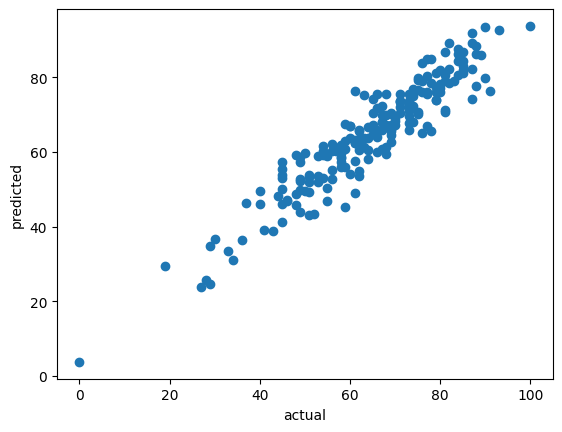

In [24]:
import matplotlib.pyplot as plt
plt.scatter(Y_test,y_pred)
plt.xlabel("actual")
plt.ylabel("predicted")

<Axes: xlabel='math score'>

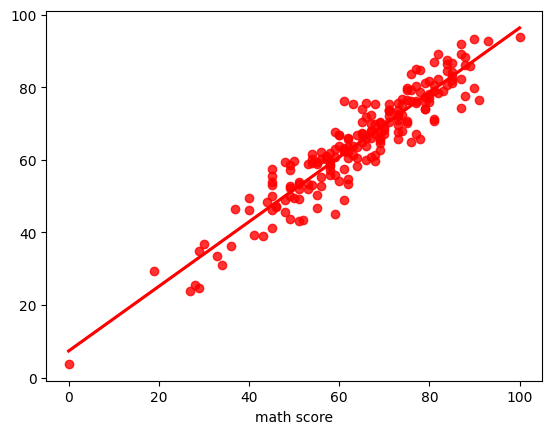

In [25]:
import seaborn as sns
sns.regplot(x=Y_test,y=y_pred,ci=None,color='r')

In [27]:
pred_df=pd.DataFrame({'actual values':Y_test,'predicted value': y_pred,'difference':Y_test-y_pred})

In [28]:
pred_df

,actual values,predicted value,difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
